# PCA for IRIS Dataset

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [5]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

In [6]:
df = pd.DataFrame(data=X, columns=feature_names)

- First Normalize the dataset i.e $\sigma = 1, \mu = 0$

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

- Then, we find the covariance matrix to find orthogonal features in the dataset i.e covariance = $\mathbf{E} [(X - \mu)(X - \mu)^{T}] $
- Note that `np.cov` requires you to compute the transpose of the argument first 

In [10]:
covar_matrix = np.cov(X_scaled.T)
print(f"CovarianceMatrix =\n {covar_matrix}")

CovarianceMatrix =
 [[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


- Next, we find the eigenvalues and eigenvectors of the covariance matrix to find the direction in which the most covariance occurs and by what values is the covariance in each direction
- We order the eigenvalues in descending order to find the components with the highest covariance in the given direction

In [15]:
eigenVals, eigenVecs = np.linalg.eig(covar_matrix)
print(f"{eigenVals}\n{eigenVecs}")

[2.93808505 0.9201649  0.14774182 0.02085386]
[[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


- Note that for a non 1D vector, : is for row/column/group start and end operator and not standard slicing operator

In [24]:
sorted_indices = np.argsort(eigenVals)[::-1]
sorted_eigenVals = eigenVals[sorted_indices]

sorted_eigenVecs = eigenVecs[:,sorted_indices]

In [27]:
n_components = 2
projection_matrix = sorted_eigenVecs[: , : n_components] # Projection of all rows but only 2 components(n_components) in a 2d representation
print(f"Projection Matrix (Top 2 Components):\n", projection_matrix)

Projection Matrix (Top 2 Components):
 [[ 0.52106591 -0.37741762]
 [-0.26934744 -0.92329566]
 [ 0.5804131  -0.02449161]
 [ 0.56485654 -0.06694199]]


- The original matrix was $n \times d$ i.e 150 $\times $ 4
- The projection matrix is $ d \times x$ i.e 4 $\times$ 2
- Converting back to the new feature space i.e 150 $\times$ 2 i.e $n \times x$, we require dot product of original matrix and projection matrix

In [28]:
X_PCA = X_scaled.dot(projection_matrix)
print(f"Transformed Data = \n{X_PCA}")

Transformed Data = 
[[-2.26470281 -0.4800266 ]
 [-2.08096115  0.67413356]
 [-2.36422905  0.34190802]
 [-2.29938422  0.59739451]
 [-2.38984217 -0.64683538]
 [-2.07563095 -1.48917752]
 [-2.44402884 -0.0476442 ]
 [-2.23284716 -0.22314807]
 [-2.33464048  1.11532768]
 [-2.18432817  0.46901356]
 [-2.1663101  -1.04369065]
 [-2.32613087 -0.13307834]
 [-2.2184509   0.72867617]
 [-2.6331007   0.96150673]
 [-2.1987406  -1.86005711]
 [-2.26221453 -2.68628449]
 [-2.2075877  -1.48360936]
 [-2.19034951 -0.48883832]
 [-1.898572   -1.40501879]
 [-2.34336905 -1.12784938]
 [-1.914323   -0.40885571]
 [-2.20701284 -0.92412143]
 [-2.7743447  -0.45834367]
 [-1.81866953 -0.08555853]
 [-2.22716331 -0.13725446]
 [-1.95184633  0.62561859]
 [-2.05115137 -0.24216355]
 [-2.16857717 -0.52714953]
 [-2.13956345 -0.31321781]
 [-2.26526149  0.3377319 ]
 [-2.14012214  0.50454069]
 [-1.83159477 -0.42369507]
 [-2.61494794 -1.79357586]
 [-2.44617739 -2.15072788]
 [-2.10997488  0.46020184]
 [-2.2078089   0.2061074 ]
 [-2.045

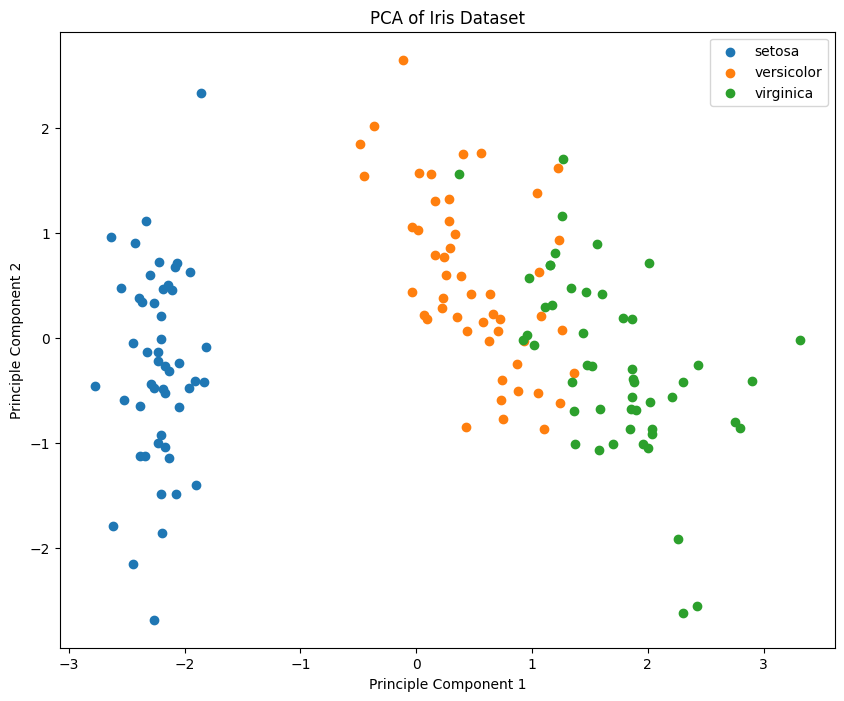

In [30]:
plt.figure(figsize=(10,8))
for target in np.unique(y):
    plt.scatter(X_PCA[y==target, 0], X_PCA[y==target, 1], label = iris.target_names[target])
plt.title("PCA of Iris Dataset")
plt.xlabel("Principle Component 1")
plt.ylabel("Principle Component 2")
plt.legend()
plt.show()

- Hence, we came to the conclusion that while PCA allowed us to seperate setosa from the other two colors we couldn't find a linearly seperable condition for virginica and versicolor. That maybe closely related to the eigenVectors.